# Step 3: Tracer advection schemes

How much does the choice of tracer advection scheme change the numerical mixing, and does any scheme create buoyancy values outside the starting range? I changed only the scheme used for buoyancy: 2nd-order centred, 3rd-order upwind-biased, and 5th-order WENO (the step 2 baseline). Momentum advection (WENO), viscosity (1e-2 m^2/s), grid (500 m x 1 m) and the 17-hour run length are the same in all three (`simulations/run_step3.jl`).

I load the libraries and the shared analysis functions, and list the runs. The centred run is the one with the wider stopping limit (explained in the next cell).

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at, density)

RUNS_BY_SCHEME = {"centred, 2nd order": "step3_tracer_centered2_wide_limit",
                  "upwind-biased, 3rd order": "step3_tracer_upwind3",
                  "WENO, 5th order": "step2_baseline_weno"}
COLORS = {"centred, 2nd order": "tab:red", "upwind-biased, 3rd order": "tab:orange", "WENO, 5th order": "tab:blue"}
FIT_START, FIT_END = 3 * 3600, 15 * 3600     # front-speed fit window (s)
FIG_DIR = "../figures"
DATA_DIR = "../data"

runs = {}
for scheme, name in RUNS_BY_SCHEME.items():
    ds, log, info = load_run(name)
    runs[scheme] = (ds, log, info)
    print(f"{scheme:26s} {name:36s} {info['status']}, {info['iterations']} iterations, "
          f"uniform tracer deviation {info['consistency_tracer_max_deviation']}")

centred, 2nd order         step3_tracer_centered2_wide_limit    completed, 1647 iterations, uniform tracer deviation 3.331e-16
upwind-biased, 3rd order   step3_tracer_upwind3                 completed, 1897 iterations, uniform tracer deviation 3.331e-16
WENO, 5th order            step2_baseline_weno                  completed, 1907 iterations, uniform tracer deviation 2.220e-16


First, what happened to the centred run with the normal stopping rule. My health check stops a run if b goes more than one buoyancy difference outside its starting range [0, 0.04905], which I had meant as a sign of blow-up. The centred run hit that limit after 59 minutes. To find out whether it was really blowing up, I repeated it with the limit widened to ten buoyancy differences (NaN still stops a run): it then ran the full 17 hours. So the centred scheme did not blow up; it carried very large overshoots.

In [2]:
ds_stop, log_stop, info_stop = load_run("step3_tracer_centered2")
print("normal limit:", info_stop["status"])
print("wide limit:  ", runs["centred, 2nd order"][2]["status"], "after", runs["centred, 2nd order"][2]["iterations"], "iterations")

normal limit: blew up: out of range at t = 3539.7 s (b in [-4.941e-02, 9.846e-02], max|u| = 0.84 m/s)
wide limit:   completed after 1647 iterations


Buoyancy after 17 hours for each scheme, on the same colour scale (0 to 0.049 m/s^2; values outside it are shown in the end colours).

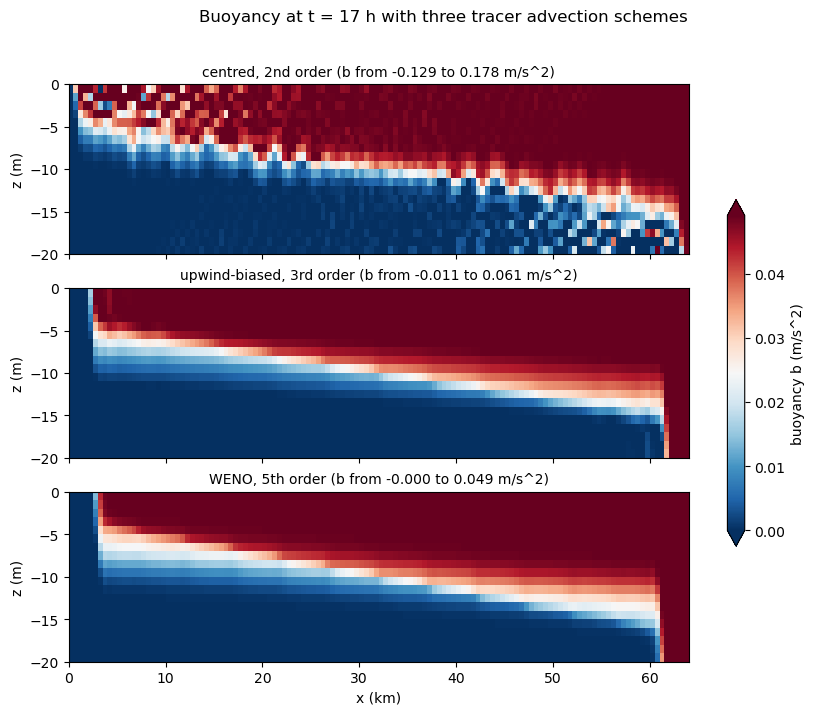

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
for ax, (scheme, (ds, log, info)) in zip(axes, runs.items()):
    snapshot = ds["b"].sel(time=17 * 3600, method="nearest")
    mesh = ax.pcolormesh(ds.x_caa / 1e3, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
    ax.set_ylabel("z (m)")
    ax.set_title(f"{scheme} (b from {float(snapshot.min()):.3f} to {float(snapshot.max()):.3f} m/s^2)", fontsize=10)
axes[-1].set_xlabel("x (km)")
fig.colorbar(mesh, ax=axes, label="buoyancy b (m/s^2)", shrink=0.6, extend="both")
fig.suptitle("Buoyancy at t = 17 h with three tracer advection schemes")
fig.savefig(os.path.join(FIG_DIR, "03_schemes_snapshots.png"), dpi=150, bbox_inches="tight")
plt.show()

Overshoots against time, from the log (every 10 iterations): how far the smallest b went below 0 and the largest above 0.04905, as a fraction of the buoyancy difference. A scheme that never creates new extremes would stay at zero (it cannot be drawn on a log axis, so a value of 0 simply does not appear). The lines for 'below 0' and 'above the maximum' lie on top of each other, because the two currents are mirror images.

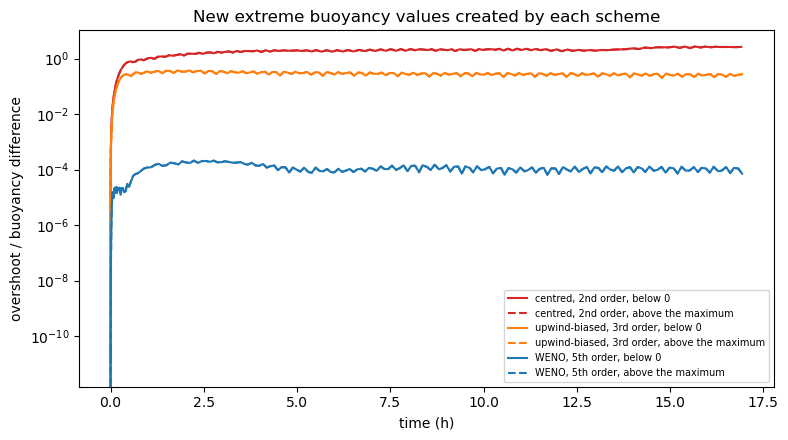

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for scheme, (ds, log, info) in runs.items():
    under = np.maximum(-log["b_min"], 0) / DELTA_B
    over = np.maximum(log["b_max"] - DELTA_B, 0) / DELTA_B
    ax.semilogy(log["time_s"] / 3600, under, color=COLORS[scheme], label=f"{scheme}, below 0")
    ax.semilogy(log["time_s"] / 3600, over, color=COLORS[scheme], ls="--", label=f"{scheme}, above the maximum")
ax.set_xlabel("time (h)")
ax.set_ylabel("overshoot / buoyancy difference")
ax.set_title("New extreme buoyancy values created by each scheme")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_schemes_overshoots.png"), dpi=150)
plt.show()

RPE change and buoyancy variance change against time for the three schemes.

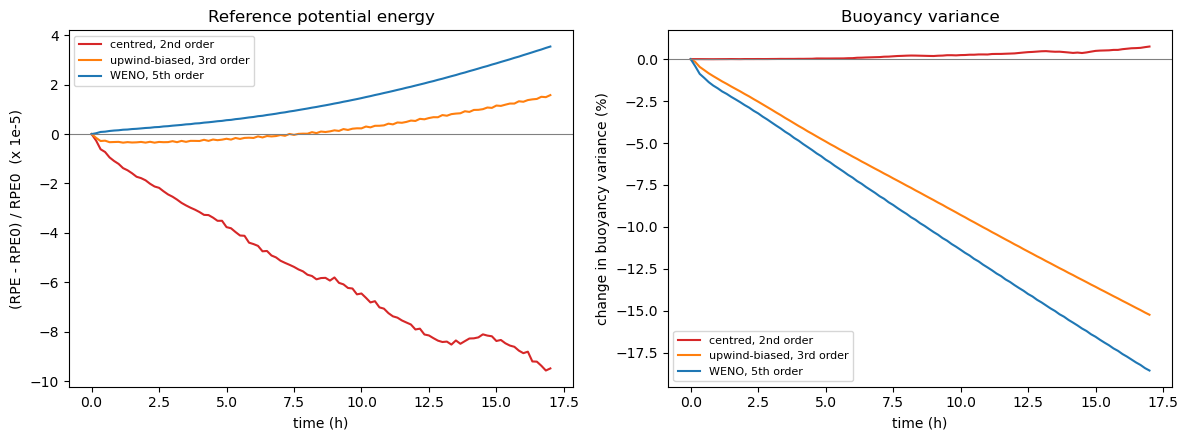

In [5]:
results = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for scheme, (ds, log, info) in runs.items():
    times = ds.time.values
    rpe = rpe_series(ds)
    variance = buoyancy_variance(ds)
    right, left = front_positions(ds)
    results[scheme] = {"times": times, "rpe": rpe, "variance": variance, "right": right, "left": left}
    axes[0].plot(times / 3600, (rpe - rpe[0]) / rpe[0] * 1e5, color=COLORS[scheme], label=scheme)
    axes[1].plot(times / 3600, 100 * (variance - variance[0]) / variance[0], color=COLORS[scheme], label=scheme)
axes[0].axhline(0, color="0.5", lw=0.8)
axes[0].set_xlabel("time (h)")
axes[0].set_ylabel("(RPE - RPE0) / RPE0  (x 1e-5)")
axes[0].set_title("Reference potential energy")
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].set_xlabel("time (h)")
axes[1].set_ylabel("change in buoyancy variance (%)")
axes[1].set_title("Buoyancy variance")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_schemes_rpe_variance.png"), dpi=150)
plt.show()

The centred run's RPE goes DOWN and its variance goes UP, which mixing alone can never do. The reason is the overshoots: the centred scheme creates water denser than the densest and lighter than the lightest starting water. In the sorted state that extra-dense water sits at the very bottom and the extra-light water at the top, which lowers the centre of mass, the opposite of mixing ("anti-diffusion"). Ilicak et al. (2012, Section 3.5) found the same with an unlimited scheme: it "may appear to have less mixing from an integrated energetic point of view", but only because new extremes offset the mixing.

The clearest way to see both effects is the distribution of densities, as in Ilicak et al. (2012, Fig. 7): at the start half the water is 995 kg/m^3 and half 1000 kg/m^3. Mixing fills in the values between; overshoots create values outside. I count a cell as mixed, or as outside, only if it is more than 1% of the density difference (0.05 kg/m^3) inside or outside the starting range.

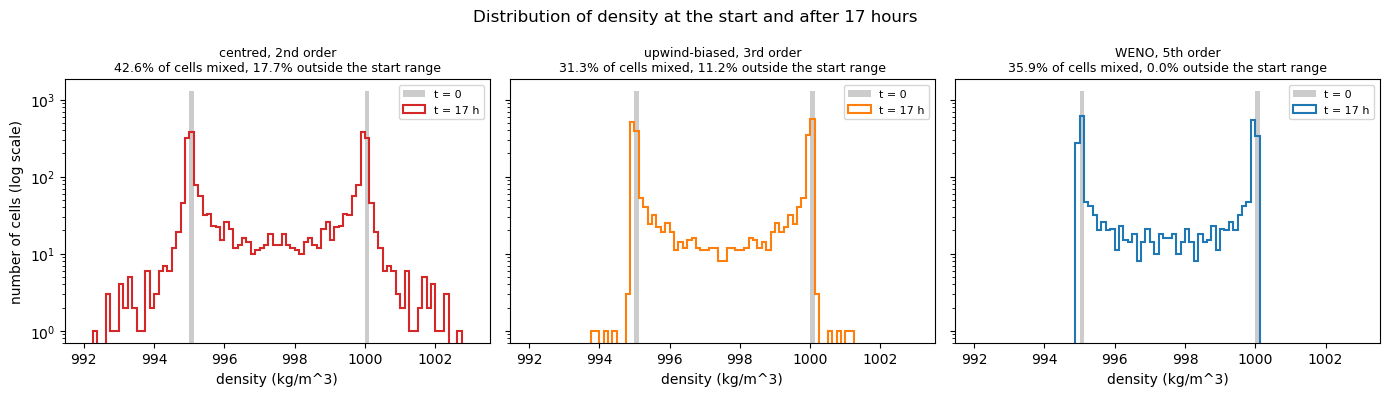

In [6]:
bins = np.linspace(density(1.6 * DELTA_B), density(-0.6 * DELTA_B), 89)    # densities from 992 to 1003 kg/m^3
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (scheme, (ds, log, info)) in zip(axes, runs.items()):
    rho_start = density(ds["b"].isel(time=0).values.ravel())
    rho_end = density(ds["b"].sel(time=17 * 3600, method="nearest").values.ravel())
    margin = 0.01 * (density(0.0) - density(DELTA_B))          # 1% of the density difference, 0.05 kg/m^3
    outside = np.mean((rho_end > density(0.0) + margin) | (rho_end < density(DELTA_B) - margin))
    between = np.mean((rho_end > density(DELTA_B) + margin) & (rho_end < density(0.0) - margin))
    ax.hist(rho_start, bins=bins, color="0.8", label="t = 0")
    ax.hist(rho_end, bins=bins, histtype="step", color=COLORS[scheme], lw=1.5, label="t = 17 h")
    ax.set_yscale("log")
    ax.set_xlabel("density (kg/m^3)")
    ax.set_title(f"{scheme}\n{100 * between:.1f}% of cells mixed, {100 * outside:.1f}% outside the start range", fontsize=9)
    ax.legend(fontsize=8)
axes[0].set_ylabel("number of cells (log scale)")
fig.suptitle("Distribution of density at the start and after 17 hours")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "03_schemes_density_pdf.png"), dpi=150)
plt.show()

A table of all three runs, saved to `data/step3_schemes.csv`.

In [7]:
rows = []
for scheme, (ds, log, info) in runs.items():
    r = results[scheme]
    t = r["times"]
    rows.append({"scheme": scheme,
                 "rpe_change_17h": (r["rpe"][-1] - r["rpe"][0]) / r["rpe"][0],
                 "drpe_dt_17h_W_m2": rpe_rate_at(t, r["rpe"], 17 * 3600, 3600) / LENGTH,
                 "rpe_smallest_step": np.min(np.diff(r["rpe"])) / r["rpe"][0],
                 "variance_change_17h": (r["variance"][-1] - r["variance"][0]) / r["variance"][0],
                 "undershoot": max(-log["b_min"].min(), 0) / DELTA_B,
                 "overshoot": max(log["b_max"].max() - DELTA_B, 0) / DELTA_B,
                 "front_speed_m_s": front_speed(t, r["right"], FIT_START, FIT_END),
                 "total_b_drift": np.max(np.abs(log["b_total_m3_per_s2"] - log["b_total_m3_per_s2"].iloc[0])) / log["b_total_m3_per_s2"].iloc[0],
                 "iterations": int(info["iterations"]),
                 "wall_time_s": float(info["wall_time_s"])})
table = pd.DataFrame(rows)
table.to_csv(os.path.join(DATA_DIR, "step3_schemes.csv"), index=False)
u_theory = 0.5 * np.sqrt(DELTA_B * DEPTH)
for row in rows:
    print(f"{row['scheme']:26s} RPE {row['rpe_change_17h']:+.3e} | dRPE/dt {row['drpe_dt_17h_W_m2']:+.3e} W/m^2 | "
          f"smallest RPE step {row['rpe_smallest_step']:+.1e} | variance {100 * row['variance_change_17h']:+.2f}% | "
          f"under/overshoot {row['undershoot']:.2e}/{row['overshoot']:.2e} | front {row['front_speed_m_s']:.4f} m/s "
          f"({100 * (row['front_speed_m_s'] / u_theory - 1):+.1f}%) | buoyancy drift {row['total_b_drift']:.1e}")

centred, 2nd order         RPE -9.485e-05 | dRPE/dt -4.132e-03 W/m^2 | smallest RPE step -4.0e-06 | variance +0.75% | under/overshoot 2.74e+00/2.74e+00 | front 0.5125 m/s (+3.5%) | buoyancy drift 1.8e-08
upwind-biased, 3rd order   RPE +1.577e-05 | dRPE/dt +1.337e-03 W/m^2 | smallest RPE step -1.5e-06 | variance -15.24% | under/overshoot 3.79e-01/3.79e-01 | front 0.4881 m/s (-1.4%) | buoyancy drift 1.8e-08
WENO, 5th order            RPE +3.543e-05 | dRPE/dt +1.890e-03 W/m^2 | smallest RPE step +7.6e-08 | variance -18.56% | under/overshoot 2.11e-04/2.11e-04 | front 0.4793 m/s (-3.2%) | buoyancy drift 1.8e-08


## Link to my MITgcm blow-up (project 15)

In project 15, one hosing run with mixed boundary conditions blew up in a single water column next to the 80°N wall, under an extremely fresh surface layer, with the tutorial's centred advection scheme; rerun with a flux-limited scheme it stayed stable. This step shows the mechanism in a clean setting. Moving a sharp front, the centred scheme puts values far outside the physical range (here up to 2.7 buoyancy differences beyond it) because it has no way to stop wiggles at a jump. In a salinity field next to a very fresh layer, such wiggles mean unphysical salinities and densities, which then drive the flow. Here the lock exchange survived the overshoots, but they are a ready source of trouble when the flow is stronger or the forcing keeps sharpening the front, as in the MITgcm run.